In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib as mpl
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen, add_image
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from highlight_text import ax_text, fig_text
from PIL import Image
from mplsoccer import add_image
from urllib.request import urlopen
import os
from adjustText import adjust_text
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Print the modified DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

green = '#69f900'
red = '#ff4b44'
blue = '#00a0de'
violet = '#a369ff'
bg_color= '#f5f5f5'
line_color= '#000000'
col1 = '#ff4b44'
col2 = '#00a0de'

In [3]:
font_path = r"C:\Fonts\Noto_Sans\static\NotoSans-Bold.ttf"
custom_font = FontProperties(fname=font_path)
font_path_thin = r"C:\Fonts\Noto_Sans\static\NotoSans-Regular.ttf"
custom_font_thin = FontProperties(fname=font_path_thin)

In [4]:
df = pd.read_csv(r"D:\FData\All_Top_5_League\2024_25\event_data\Premier_League_2024_25_event_data.csv")

C:\Users\h\AppData\Local\Temp\ipykernel_9628\2731803387.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\FData\All_Top_5_League\2024_25\event_data\Premier_League_2024_25_event_data.csv")


In [51]:
df = pd.read_csv(r"D:\FData\All_Top_5_League\2024_25\event_data\Ligue_1_2024_25_event_data.csv")

C:\Users\h\AppData\Local\Temp\ipykernel_9628\2021750896.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\FData\All_Top_5_League\2024_25\event_data\Ligue_1_2024_25_event_data.csv")


In [52]:
df = df[['matchId', 'minute', 'second', 'x', 'y', 'endX', 'endY', 
        'blockedX', 'blockedY', 'goalMouthZ', 'goalMouthY', 
        'type', 'outcomeType', 
        'qualifiers', 'satisfiedEventsTypes', 
        'teamName', 'oppositionTeamName', 'playerName', 'shirtNo', 'position', 'shortName', 'possession_id']]

In [6]:
df_teamNameId = pd.read_csv(r"D:\FData\club_teams_logo\teams_name_and_id.csv")

# Fast Break

In [9]:
fb = df[(df['type'].isin(['Goal', 'MissedShots', 'SavedShot', 'ShotOnPost'])) & (df['qualifiers'].str.contains('FastBreak'))]
fb['matchId'].value_counts()

matchId
1821318.0    8
1821172.0    7
1821308.0    7
1821206.0    6
1821236.0    6
1821230.0    6
1821266.0    5
1821428.0    5
1821211.0    5
1821117.0    5
1821276.0    5
1821385.0    5
1821068.0    5
1821180.0    5
1821357.0    5
1821323.0    5
1821057.0    5
1821261.0    5
1821218.0    5
1821062.0    5
1821328.0    5
1821142.0    4
1821271.0    4
1821411.0    4
1821106.0    4
1821247.0    4
1821192.0    4
1821191.0    4
1821258.0    4
1821137.0    4
1821245.0    4
1821327.0    4
1821418.0    4
1821421.0    4
1821119.0    4
1821154.0    4
1821144.0    4
1821415.0    4
1821088.0    4
1821072.0    4
1821282.0    4
1821283.0    4
1821069.0    4
1821066.0    4
1821284.0    4
1821370.0    4
1821073.0    4
1821296.0    4
1821336.0    4
1821082.0    4
1821242.0    4
1821389.0    4
1821413.0    4
1821342.0    4
1821280.0    3
1821281.0    3
1821122.0    3
1821155.0    3
1821306.0    3
1821260.0    3
1821269.0    3
1821220.0    3
1821396.0    3
1821241.0    3
1821213.0    3
1821315.0    3
18

In [4]:
m1 = df[df['matchId']==1821318]
m1.head()

,level_0,index,eventId,minute,second,teamId,h_a,x,y,expandedMinute,period,type,outcomeType,qualifiers,satisfiedEventsTypes,isTouch,playerId,playerName,shirtNo,position,age,isFirstEleven,endX,endY,blockedX,blockedY,goalMouthZ,goalMouthY,isShot,relatedEventId,relatedPlayerId,isGoal,cardType,isOwnGoal,cumulative_mins,matchId,startDate,startTime,score,ftScore,htScore,etScore,venueName,maxMinute,x1_bin_xT,y1_bin_xT,x2_bin_xT,y2_bin_xT,start_zone_value_xT,end_zone_value_xT,xT,shortName,teamName,oppositionTeamName,prog_pass,prog_carry,pass_or_carry_angle,possession_id,possession_team
390708,0,1,3.0,0.0,0.0,189,h,0.000,0.000,0.0,FirstHalf,Start,Successful,[],[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,False,NaN,0.00,1821318.0,2025-01-18T00:00:00,2025-01-18T15:00:00,0 : 2,0 : 2,0 : 0,NaN,Gtech Community Stadium,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Brentford,Liverpool,0.000000,0.0,NaN,1.0,Liverpool
390709,1,2,3.0,0.0,0.0,26,a,0.000,0.000,0.0,FirstHalf,Start,Successful,[],[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,False,NaN,0.00,1821318.0,2025-01-18T00:00:00,2025-01-18T15:00:00,0 : 2,0 : 2,0 : 0,NaN,Gtech Community Stadium,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,Brentford,0.000000,0.0,NaN,1.0,Liverpool
390710,2,3,4.0,0.0,0.0,26,a,52.500,34.000,0.0,FirstHalf,Pass,Successful,"[{'type': {'value': 178, 'displayName': 'Stand...","['touches', 'passAccurate', 'shortPassAccurate...",True,369875.0,Dominik Szoboszlai,8.0,AMC,24.0,True,24.675,32.368,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,False,NaN,0.00,1821318.0,2025-01-18T00:00:00,2025-01-18T15:00:00,0 : 2,0 : 2,0 : 0,NaN,Gtech Community Stadium,95.0,6.0,3.0,2.0,3.0,0.016895,0.010165,-0.006730,D. Szoboszlai,Liverpool,Brentford,-27.841577,0.0,-176.643317,1.0,Liverpool
390711,3,4,5.0,0.0,3.0,26,a,25.200,32.300,0.0,FirstHalf,Pass,Successful,"[{'type': {'value': 213, 'displayName': 'Angle...","['touches', 'passForwardZoneAccurate', 'passAc...",True,114147.0,Alisson Becker,1.0,GK,32.0,True,68.145,62.424,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,False,NaN,0.05,1821318.0,2025-01-18T00:00:00,2025-01-18T15:00:00,0 : 2,0 : 2,0 : 0,NaN,Gtech Community Stadium,95.0,2.0,3.0,7.0,7.0,0.010165,0.017451,0.007285,A. Becker,Liverpool,Brentford,33.275493,0.0,35.047945,1.0,Liverpool
390712,4,5,6.0,0.0,6.0,26,a,68.145,62.424,0.0,FirstHalf,Pass,Unsuccessful,"[{'type': {'value': 141, 'displayName': 'PassE...","['touches', 'passInaccurate', 'shortPassInaccu...",True,352825.0,Cody Gakpo,18.0,AML,26.0,True,76.335,58.072,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,False,NaN,0.10,1821318.0,2025-01-18T00:00:00,2025-01-18T15:00:00,0 : 2,0 : 2,0 : 0,NaN,Gtech Community Stadium,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C. Gakpo,Liverpool,Brentford,9.110763,0.0,-27.985271,1.0,Liverpool


In [11]:
fb = m1[(m1['type'].isin(['Goal', 'MissedShots', 'SavedShot', 'ShotOnPost'])) & (m1['qualifiers'].str.contains('FastBreak'))]
fb.possession_id.unique()

array([ 17.,  47.,  61.,  71.,  73.,  74.,  93., 105.])

Pass
Clearance

TakeOn
BallTouch
BallRecovery

Shots

Remove:
Aerial
Corner Awarded

In [28]:
test = m1[(m1['possession_id']==6) & (m1['teamName']==m1['possession_team'])].reset_index(drop=True)
test.type.unique()

array(['BallRecovery', 'TakeOn', 'Foul', 'Pass', 'Aerial'], dtype=object)

In [51]:
test = m1[
    (m1['possession_id']==6) 
    # & (m1['teamName']==m1['possession_team'])
    ].reset_index(drop=True)
test = test[['minute', 'second', 'x', 'y', 'endX', 'endY', 
             #'blockedX', 'blockedY', 'goalMouthZ', 'goalMouthY', 
             'type', 'outcomeType', 
             # 'qualifiers', 'satisfiedEventsTypes', 
             'teamName', 'playerName', 'shirtNo', 'position', 'shortName']]
test

,minute,second,x,y,endX,endY,type,outcomeType,teamName,playerName,shirtNo,position,shortName
0,1.0,53.0,11.445,61.812,11.445,61.812,BallRecovery,Successful,Brentford,Yehor Yarmoliuk,18.0,AML,Y. Yarmoliuk
1,1.0,57.0,14.385,63.512,NaN,NaN,TakeOn,Unsuccessful,Brentford,Yehor Yarmoliuk,18.0,AML,Y. Yarmoliuk
2,1.0,58.0,15.120,61.744,NaN,NaN,Foul,Successful,Brentford,Yehor Yarmoliuk,18.0,AML,Y. Yarmoliuk
3,1.0,58.0,89.880,6.256,NaN,NaN,Foul,Unsuccessful,Liverpool,Cody Gakpo,18.0,AML,C. Gakpo
4,2.0,29.0,15.015,60.928,74.445,64.940,Pass,Successful,Brentford,Mark Flekken,1.0,GK,M. Flekken
5,2.0,33.0,72.765,64.532,NaN,NaN,Aerial,Successful,Brentford,Keane Lewis-Potter,23.0,DL,K. Lewis-Potter
6,2.0,33.0,32.235,3.468,NaN,NaN,Aerial,Unsuccessful,Liverpool,Trent Alexander-Arnold,66.0,DR,T. Alexander-Arnold
7,2.0,33.0,74.445,64.940,69.615,52.088,Pass,Unsuccessful,Brentford,Keane Lewis-Potter,23.0,DL,K. Lewis-Potter
8,2.0,34.0,34.125,18.428,65.100,8.364,Pass,Unsuccessful,Liverpool,Alexis Mac Allister,10.0,DMC,A. M. Allister
9,2.0,37.0,36.645,56.712,42.735,61.200,Pass,Successful,Brentford,Sepp van den Berg,4.0,DC,S. v. den Berg


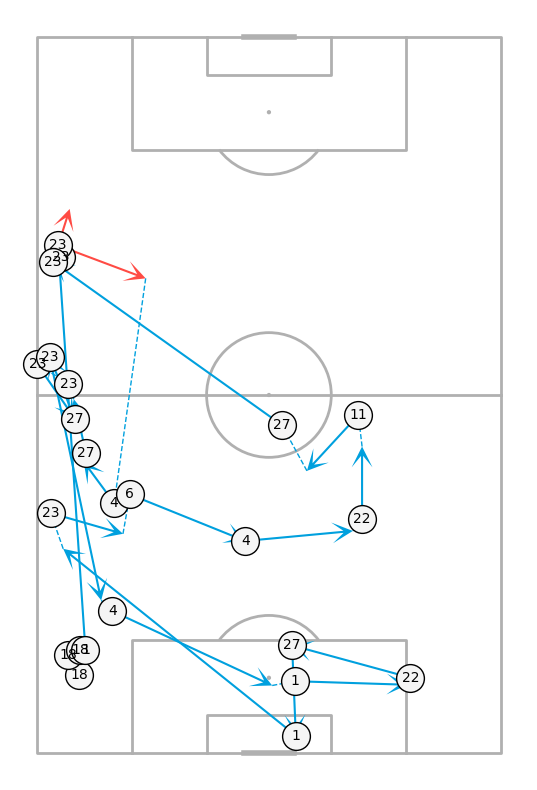

In [49]:
fig, ax = plt.subplots(figsize=(10,10))

pitch = VerticalPitch(pitch_type='uefa')
pitch.draw(ax=ax)

rows = list(test.iterrows())  # Convert to list for easier indexing

for i, (index, row) in enumerate(rows):
    if i < len(rows) - 1:  # Make sure there's a next row
        next_index, next_row = rows[i + 1]
    
    if row['type'] not in ['Pass', 'Clearance']:
        pitch.scatter(row['x'], row['y'], s=400, color=bg_color, edgecolor=line_color, zorder=5, ax=ax)
        ax.text(row['y'], row['x'], f"{int(row['shirtNo'])}", fontsize=10, ha='center', va='center', zorder=6)
        if i < len(rows) - 1:  # Only draw line if there's a next row
            pitch.lines(row['x'], row['y'], next_row['x'], next_row['y'], color=col2, linewidth=1, linestyle='--', zorder=3, ax=ax)
    
    if (row['type'] in ['Pass', 'Clearance'] and row['outcomeType']=='Successful'):
        pitch.scatter(row['x'], row['y'], s=400, color=bg_color, edgecolor=line_color, zorder=5, ax=ax)
        ax.text(row['y'], row['x'], f"{int(row['shirtNo'])}", fontsize=10, ha='center', va='center', zorder=6)
        pitch.arrows(row['x'], row['y'], row['endX'], row['endY'], color=col2, width=1.5, headlength=10, headwidth=10, zorder=3, ax=ax)
        if i < len(rows) - 1:  # Only draw line if there's a next row
            pitch.lines(row['endX'], row['endY'], next_row['x'], next_row['y'], color=col2, linewidth=1, linestyle='--', zorder=3, ax=ax)

    if (row['type'] in ['Pass', 'Clearance'] and row['outcomeType']=='Unsuccessful'):
        pitch.scatter(row['x'], row['y'], s=400, color=bg_color, edgecolor=line_color, zorder=5, ax=ax)
        ax.text(row['y'], row['x'], f"{int(row['shirtNo'])}", fontsize=10, ha='center', va='center', zorder=6)
        pitch.arrows(row['x'], row['y'], row['endX'], row['endY'], color=col1, width=1.5, headlength=10, headwidth=10, zorder=3, ax=ax)
        if i < len(rows) - 1:  # Only draw line if there's a next row
            pitch.lines(row['endX'], row['endY'], next_row['x'], next_row['y'], color=col2, linewidth=1, linestyle='--', zorder=3, ax=ax)

# Build-up Pos Chain Viz

In [8]:
df.teamName.unique()

array(['Man Utd', 'Fulham', 'Ipswich', 'Liverpool', 'Aston Villa',
       'West Ham', 'Arsenal', 'Wolves', 'Southampton', 'Newcastle',
       'Everton', 'Brighton', 'Bournemouth', 'Nottingham Forest',
       'Crystal Palace', 'Brentford', 'Man City', 'Chelsea', 'Leicester',
       'Tottenham'], dtype=object)

In [33]:
team_name = "Liverpool"
teamdf = df[(df['teamName']==team_name) | (df['oppositionTeamName']==team_name)]
teamdf = teamdf[teamdf['type']!='Carry'].reset_index(drop=True)

mids = teamdf.matchId.unique()

def calculater_avg_pass(mid):
    mdf = teamdf[teamdf['matchId']==mid].reset_index(drop=True)
    passdf = mdf[(mdf['type']=='Pass') & (mdf['teamName']==team_name)]
    passes_per_pos = passdf.groupby("possession_id").size()
    avg_passes_per_pos = int(round(passes_per_pos.median(), 0))
    max_passes_per_pos = int(round(passes_per_pos.max(), 0))
    return avg_passes_per_pos, max_passes_per_pos

team_dict = {'mid': [], 'avg_pass_per_pos': [], 'max_passes_per_pos': []}
for mid in mids:
    avg_passes_per_pos, max_passes_per_pos = calculater_avg_pass(mid)
    team_dict['mid'].append(mid)
    team_dict['avg_pass_per_pos'].append(avg_passes_per_pos)
    team_dict['max_passes_per_pos'].append(max_passes_per_pos)

team_df = pd.DataFrame(team_dict)
team_df.head()

,mid,avg_pass_per_pos,max_passes_per_pos
0,1821050.0,5,88
1,1821064.0,5,38
2,1821070.0,3,34
3,1821088.0,8,33
4,1821095.0,6,29


In [35]:
round(team_df['avg_pass_per_pos'].mean(), 2)

5.11

In [25]:
m1 = df[df['matchId']==1821171]
# def find_that_pos(pos_id):
for i in range(int(m1['possession_id'].max())):
    test = m1[
        (m1['possession_id']==i) 
        # & (m1['teamName']==m1['possession_team'])
        ].reset_index(drop=True)
    if len(test) > 100:
        print(test['possession_id'].unique()[0])
    else:
        i = i + 1

34.0


In [ ]:
test = m1[
    (m1['possession_id']==34) 
    & (m1['teamName']==m1['possession_team'])
    ].reset_index(drop=True)
test = test[['minute', 'second', 'x', 'y', 'endX', 'endY', 
             #'blockedX', 'blockedY', 'goalMouthZ', 'goalMouthY', 
             'type', 'outcomeType', 
             # 'qualifiers', 'satisfiedEventsTypes', 
             'teamName', 'playerName', 'shirtNo', 'position', 'shortName']]
test

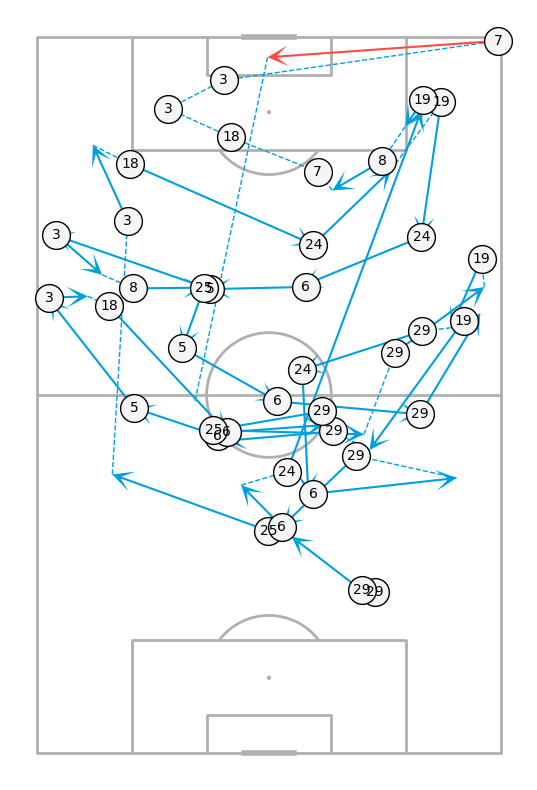

In [33]:
fig, ax = plt.subplots(figsize=(10,10))

pitch = VerticalPitch(pitch_type='uefa')
pitch.draw(ax=ax)

rows = list(test.iterrows())  # Convert to list for easier indexing

for i, (index, row) in enumerate(rows):
    if i < len(rows) - 1:  # Make sure there's a next row
        next_index, next_row = rows[i + 1]
    
    if row['type'] not in ['Pass', 'Clearance']:
        pitch.scatter(row['x'], row['y'], s=400, color=bg_color, edgecolor=line_color, zorder=5, ax=ax)
        ax.text(row['y'], row['x'], f"{int(row['shirtNo'])}", fontsize=10, ha='center', va='center', zorder=6)
        if i < len(rows) - 1:  # Only draw line if there's a next row
            pitch.lines(row['x'], row['y'], next_row['x'], next_row['y'], color=col2, linewidth=1, linestyle='--', zorder=3, ax=ax)
    
    if (row['type'] in ['Pass', 'Clearance'] and row['outcomeType']=='Successful'):
        pitch.scatter(row['x'], row['y'], s=400, color=bg_color, edgecolor=line_color, zorder=5, ax=ax)
        ax.text(row['y'], row['x'], f"{int(row['shirtNo'])}", fontsize=10, ha='center', va='center', zorder=6)
        pitch.arrows(row['x'], row['y'], row['endX'], row['endY'], color=col2, width=1.5, headlength=10, headwidth=10, zorder=3, ax=ax)
        if i < len(rows) - 1:  # Only draw line if there's a next row
            pitch.lines(row['endX'], row['endY'], next_row['x'], next_row['y'], color=col2, linewidth=1, linestyle='--', zorder=3, ax=ax)

    if (row['type'] in ['Pass', 'Clearance'] and row['outcomeType']=='Unsuccessful'):
        pitch.scatter(row['x'], row['y'], s=400, color=bg_color, edgecolor=line_color, zorder=5, ax=ax)
        ax.text(row['y'], row['x'], f"{int(row['shirtNo'])}", fontsize=10, ha='center', va='center', zorder=6)
        pitch.arrows(row['x'], row['y'], row['endX'], row['endY'], color=col1, width=1.5, headlength=10, headwidth=10, zorder=3, ax=ax)
        if i < len(rows) - 1:  # Only draw line if there's a next row
            pitch.lines(row['endX'], row['endY'], next_row['x'], next_row['y'], color=col2, linewidth=1, linestyle='--', zorder=3, ax=ax)
        break

# Involvement in Build-up from the Back

In [102]:
def avg_chain_len_per_team(team_name):
    teamdf = df[(df['teamName']==team_name) | (df['oppositionTeamName']==team_name)]
    teamdf = teamdf[teamdf['type']!='Carry'].reset_index(drop=True)
    mids = teamdf.matchId.unique()
    avg_pass_per_match_list = []
    for mid in mids:
        m1 = df[df['matchId']==mid]

        pass_per_buildup_from_back_list = []
        for i in range(int(m1['possession_id'].max())):
            pass_df = m1[(m1['type']=='Pass') & 
                    (m1['possession_id']==i) & 
                    (m1['teamName']==team_name)].reset_index(drop=True)
            if (len(pass_df) >= 1) and (pass_df.loc[0, 'endX']<=35):
                pass_per_buildup_from_back = len(pass_df)
                pass_per_buildup_from_back_list.append(pass_per_buildup_from_back)

        avg_pass_per_buildup_from_back = int(np.mean(pass_per_buildup_from_back_list))
        avg_pass_per_match_list.append(avg_pass_per_buildup_from_back)
    team_avg_pass = int(np.mean(avg_pass_per_match_list))
    return team_avg_pass


teams = df.teamName.unique()
team_dict = {'team_name': [], 'team_avg_pass': []}
for team_name in teams:
    team_dict['team_name'].append(team_name)
    team_avg_pass = avg_chain_len_per_team(team_name)
    team_dict['team_avg_pass'].append(team_avg_pass)

team_df = pd.DataFrame(team_dict)
team_df

,team_name,team_avg_pass
0,Man Utd,8
1,Fulham,8
2,Ipswich,6
3,Liverpool,9
4,Aston Villa,8
5,West Ham,7
6,Arsenal,10
7,Wolves,7
8,Southampton,8
9,Newcastle,8


In [ ]:
# Sort by average passes for better visualization
df_sorted = team_df.sort_values('team_avg_pass', ascending=True)

# Create the bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(df_sorted['team_name'], df_sorted['team_avg_pass'], 
                color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)

# Customize the chart
plt.xlabel('Pass Count', fontsize=12, fontweight='bold')
plt.ylabel('Team Name', fontsize=12, fontweight='bold')
plt.title('Avg. Passes while Build-up from the Back', fontsize=14, fontweight='bold', pad=20)

# Add value labels on the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center', fontsize=9)

# Improve layout
plt.tight_layout()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Show the plot
plt.show()

# Build-up Contribution

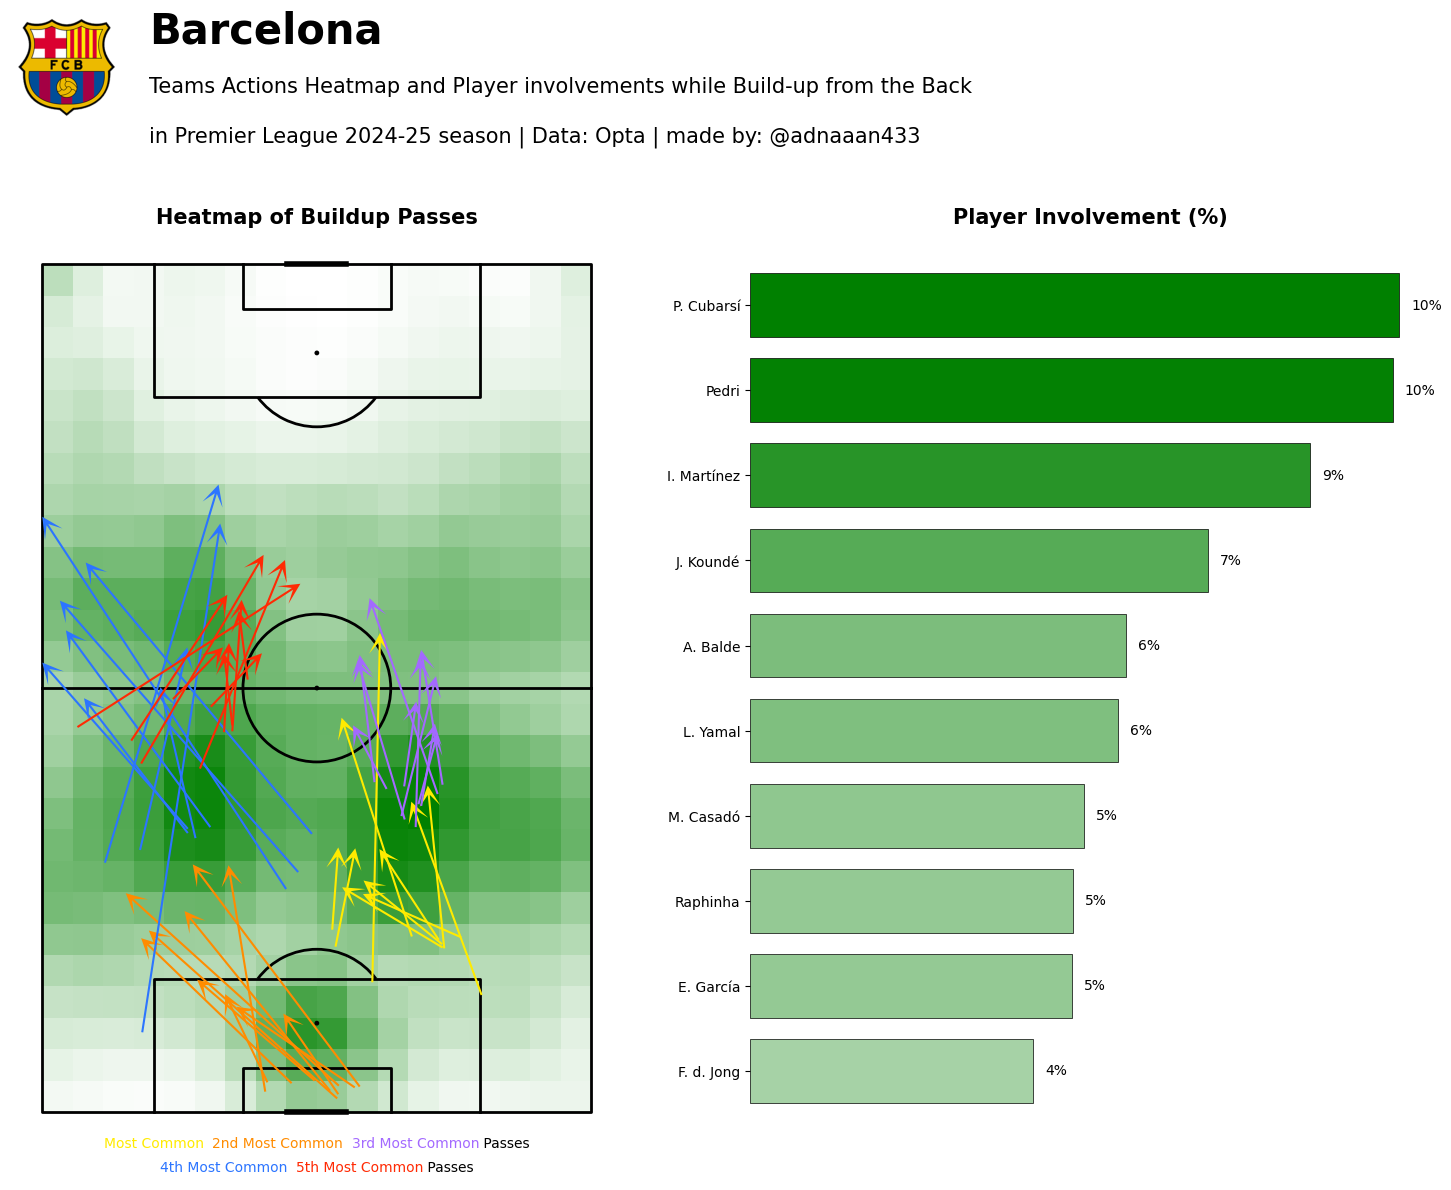

In [40]:
def buildup_contr(team_name, ax1, ax2):
    # filter the team's data
    teamdf = df[(df['teamName']==team_name) | (df['oppositionTeamName']==team_name)]
    
    # get the match IDs
    mids = teamdf.matchId.unique()

    avg_pass_per_match_list = []
    for mid in mids:
        m1 = df[df['matchId']==mid]

        pass_per_buildup_from_back_list = []
        possession_ids = m1['possession_id'].dropna()
        if len(possession_ids) == 0:
            continue
        max_pos = int(possession_ids.max())
        for i in range(max_pos):
            pass_df = m1[(m1['type']=='Pass') & (~m1['qualifiers'].str.contains('Corner')) &
                    (m1['possession_id']==i) & 
                    (m1['teamName']==team_name)].reset_index(drop=True)
            if (len(pass_df) >= 1) and (pass_df.loc[0, 'endX']<=35):
                pass_per_buildup_from_back = len(pass_df)
                pass_per_buildup_from_back_list.append(pass_per_buildup_from_back)

        if len(pass_per_buildup_from_back_list) != 0:
            avg_pass_per_buildup_from_back = int(np.mean(pass_per_buildup_from_back_list))
        avg_pass_per_match_list.append(avg_pass_per_buildup_from_back)
    team_avg_pass = int(np.mean(avg_pass_per_match_list))
    
    buildup_dfs = []
    plot_dfs = []
    # get dataframe for each match
    for mid in mids:
        m1 = df[df['matchId']==mid]
        
        # Check if possession_id column exists and has valid data
        if 'possession_id' not in m1.columns:
            continue
            
        # Get max possession_id, handling NaN case
        possession_ids = m1['possession_id'].dropna()
        if len(possession_ids) == 0:
            continue  # Skip if no valid possession_id values
            
        max_pos = int(possession_ids.max())
        
        for i in range(max_pos):
            buildup_pass_df = m1[(m1['type']=='Pass') & (m1['possession_id']==i) & (m1['teamName']==team_name)].reset_index(drop=True)
            
            # check if the dataframe meets the condition
            if (len(buildup_pass_df) >= team_avg_pass) and (buildup_pass_df.loc[0, 'endX']<=35):
                buildup_dfs.append(buildup_pass_df)
                plot_dfs_1 = buildup_pass_df.head(team_avg_pass)
                plot_dfs.append(plot_dfs_1)
    
    # Combine all dataframes and create result DataFrame
    if buildup_dfs:
        contr_df = pd.concat(buildup_dfs, ignore_index=True)
        contr_value = contr_df['shortName'].value_counts()
        
        # Create DataFrame with counts and percentages
        result_df = pd.DataFrame({
            'Player': contr_value.index,
            'Contribution in Build-up': contr_value.values,
            'Percentage': (contr_value.values / contr_value.sum() * 100).round(2)
        })

        top10 = result_df.head(10)

        plot_dfs_all = pd.concat(plot_dfs, ignore_index=True)

        # Viz
        pitch = VerticalPitch(pitch_type='uefa', pitch_color='#ffffff', line_color=line_color, line_zorder=3)
        pitch.draw(ax=ax1)

        # pitch.arrows(contr_df.x, contr_df.y, contr_df.endX, contr_df.endY, color=col2, width=1.5, headlength=10, headwidth=10, zorder=3, ax=ax)
        flamingo_cmap = LinearSegmentedColormap.from_list("Flamingo - 100 colors", ['#ffffff', 'green'], N=250)
        bin_statistic = pitch.bin_statistic(plot_dfs_all.x, plot_dfs_all.y, statistic='count', bins=(27, 18))
        
        bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
        pitch.heatmap(bin_statistic, ax=ax1, cmap=flamingo_cmap, edgecolors='None', alpha=1)

        ax1.set_title("Heatmap of Buildup Passes", fontsize=15, fontweight='bold')

        def cluster_dataframe_into_groups(plot_dfs_all, n_clusters=5):
            # Make a copy of the original dataframe
            df_work = plot_dfs_all.copy().reset_index(drop=True)
            
            # Extract the features for clustering (first 4 columns)
            clustering_features = df_work[['x', 'y', 'endX', 'endY']].copy()
            
            # Remove rows with any missing values in clustering features
            mask = clustering_features.isnull().any(axis=1)
            if mask.sum() > 0:
                df_work = df_work[~mask].reset_index(drop=True)
                clustering_features = clustering_features[~mask].reset_index(drop=True)
            
            # Standardize the features for better clustering results
            scaler = StandardScaler()
            features_scaled = scaler.fit_transform(clustering_features)
            
            # Perform K-means clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(features_scaled)
            
            # Add cluster labels to the dataframe
            df_work['cluster'] = cluster_labels
            
            # Get cluster sizes and sort by size (descending)
            cluster_sizes = df_work['cluster'].value_counts().sort_values(ascending=False)
            
            # Create separate dataframes for each cluster, ordered by size
            cluster_dataframes = []
            for i, (original_cluster_id, size) in enumerate(cluster_sizes.items()):
                cluster_df = df_work[df_work['cluster'] == original_cluster_id].drop('cluster', axis=1)
                cluster_dataframes.append(cluster_df.reset_index(drop=True))
            
            # Also create a mapping for reference
            cluster_mapping = {i: original_id for i, (original_id, _) in enumerate(cluster_sizes.items())}
            
            return cluster_dataframes, df_work, cluster_mapping

        # Example usage:
        # Assuming your dataframe is called 'df'
        cluster_dfs, df_with_labels, mapping = cluster_dataframe_into_groups(plot_dfs_all, n_clusters=50)

        # Access individual cluster dataframes:
        cl_0 = cluster_dfs[0]
        cl_0 = cl_0.sort_values(by='x').head(10)
        cl_1 = cluster_dfs[1]
        cl_1 = cl_1.sort_values(by='x').head(10)
        cl_2 = cluster_dfs[2]
        cl_2 = cl_2.sort_values(by='x').head(10)
        cl_3 = cluster_dfs[3]
        cl_3 = cl_3.sort_values(by='x').head(10)
        cl_4 = cluster_dfs[4]
        cl_4 = cl_4.sort_values(by='x').head(10)
        
        pitch.arrows(cl_0['x'], cl_0['y'], cl_0['endX'], cl_0['endY'], color="#FFEB00", width=1.5, headlength=10, headwidth=10, zorder=5, ax=ax1)
        pitch.arrows(cl_1['x'], cl_1['y'], cl_1['endX'], cl_1['endY'], color='#FF8C00', width=1.5, headlength=10, headwidth=10, zorder=5, ax=ax1)
        pitch.arrows(cl_2['x'], cl_2['y'], cl_2['endX'], cl_2['endY'], color=violet, width=1.5, headlength=10, headwidth=10, zorder=5, ax=ax1)
        pitch.arrows(cl_3['x'], cl_3['y'], cl_3['endX'], cl_3['endY'], color='#2C75FF', width=1.5, headlength=10, headwidth=10, zorder=5, ax=ax1)
        pitch.arrows(cl_4['x'], cl_4['y'], cl_4['endX'], cl_4['endY'], color='#FF2A04', width=1.5, headlength=10, headwidth=10, zorder=5, ax=ax1)

        ax_text(34, -3, "<Most Common>  <2nd Most Common>  <3rd Most Common> Passes", ha='center', ax=ax1, 
                highlight_textprops=[{'color': '#FFEB00'}, {'color': "#FF8C00"}, {'color': violet}])
        ax_text(34, -6, "<4th Most Common>  <5th Most Common> Passes", ha='center', ax=ax1, 
                highlight_textprops=[{'color': '#2C75FF'}, {'color': '#FF2A04'}])


        # Bars
        min_alpha = 0.35
        max_alpha = 1.0

        # Get the min and max percentage values
        min_pct = top10['Percentage'].min()
        max_pct = top10['Percentage'].max()

        # Scale percentages to alpha range (0.5 to 1.0)
        alpha_values = min_alpha + (top10['Percentage'] - min_pct) / (max_pct - min_pct) * (max_alpha - min_alpha)

        # Convert green to RGB
        green_rgb = mcolors.to_rgb('green')

        # Create RGBA colors with variable alpha
        colors_with_alpha = [(green_rgb[0], green_rgb[1], green_rgb[2], alpha) for alpha in alpha_values]

        # Create bars with color list (this approach sometimes works better)
        bars = ax2.barh(top10['Player'], top10['Percentage'], height=0.75,
                        color=colors_with_alpha, edgecolor='black', linewidth=0.5)
        # Add value labels on the bars
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax2.text(width + 0.2, bar.get_y() + bar.get_height()/2, 
                    f'{int(width)}%', ha='left', va='center', fontsize=10)
            
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['bottom'].set_visible(False)
        ax2.spines['left'].set_visible(False)
        ax2.set_xticks([])
            
        ax2.set_title("Player Involvement (%)", fontsize=15, fontweight='bold')
        ax2.invert_yaxis()
        ax2.set_facecolor('#ffffff')
        
        return
    else:
        # Return empty DataFrame if no data found
        return pd.DataFrame(columns=['Player', 'Contribution in Build-up', 'Percentage'])

# Usage
team_name = 'Barcelona'
fig, axs = plt.subplots(1, 2, figsize=(15,10), facecolor='#ffffff')
buildup_contr(team_name, axs[0], axs[1])
# Fig
fig.text(0.125, 1.15, f'{team_name}', fontsize=30, fontweight='bold')
fig.text(0.125, 1.1, f'Teams Actions Heatmap and Player involvements while Build-up from the Back' , fontsize=15)
fig.text(0.125, 1.05, f'in Premier League 2024-25 season | Data: Opta | made by: @adnaaan433' , fontsize=15)

ftmb_tid = df_teamNameId[df_teamNameId['teamName']==team_name].teamId.to_list()[0]
himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
himage = Image.open(himage)
ax_himage = add_image(himage, fig, left=0.02, bottom=1.075, width=0.1, height=0.1)


plt.tight_layout()

In [49]:
df.teamName.unique()

array(['Leverkusen', 'Borussia M.Gladbach', 'Union Berlin', 'Mainz',
       'Bochum', 'RBL', 'Stuttgart', 'Freiburg', 'Eintracht Frankfurt',
       'Borussia Dortmund', 'Hoffenheim', 'Holstein Kiel', 'Augsburg',
       'Werder Bremen', 'FC Heidenheim', 'St. Pauli', 'Wolfsburg',
       'Bayern'], dtype=object)

In [42]:
for team_name in df.teamName.unique():
    fig, axs = plt.subplots(1, 2, figsize=(15,10))
    buildup_contr(team_name, axs[0], axs[1])
    # Fig
    fig.text(0.125, 1.15, f'{team_name}', fontsize=30, fontweight='bold')
    fig.text(0.125, 1.1, f'Teams Actions Heatmap and Player involvements while Build-up from the Back' , fontsize=15)
    fig.text(0.125, 1.05, f'in La Liga 2024-25 season | Data: Opta | made by: @adnaaan433' , fontsize=15)

    ftmb_tid = df_teamNameId[df_teamNameId['teamName']==team_name].teamId.to_list()[0]
    himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
    himage = Image.open(himage)
    ax_himage = add_image(himage, fig, left=0.02, bottom=1.075, width=0.1, height=0.1)


    plt.tight_layout()
    plt.savefig(rf"D:\\FData\\All_Top_5_League\\2024_25\\Analysis\\BuildUp\\La_Liga\\{team_name}.png", bbox_inches='tight')
    plt.close()


In [53]:
from tqdm import tqdm
import time

# Get unique team names
unique_teams = df.teamName.unique()
total_teams = len(unique_teams)

print(f"Starting analysis for {total_teams} teams...")
print("=" * 50)

# Create progress bar with dynamic description
pbar = tqdm(unique_teams, desc="Processing teams", unit="team", 
            bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

for i, team_name in enumerate(pbar):
    try:
        # Update progress bar description with current team
        pbar.set_description(f"Processing: {team_name[:20]}...")
        
        fig, axs = plt.subplots(1, 2, figsize=(15,10))
        buildup_contr(team_name, axs[0], axs[1])
        
        # Fig
        fig.text(0.125, 1.15, f'{team_name}', fontsize=30, fontweight='bold')
        fig.text(0.125, 1.1, f'Teams Actions Heatmap and Player involvements while Build-up from the Back' , fontsize=15)
        fig.text(0.125, 1.05, f'in Ligue 1 2024-25 season | Data: Opta | made by: @adnaaan433' , fontsize=15)

        ftmb_tid = df_teamNameId[df_teamNameId['teamName']==team_name].teamId.to_list()[0]
        himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
        himage = Image.open(himage)
        ax_himage = add_image(himage, fig, left=0.02, bottom=1.075, width=0.1, height=0.1)

        plt.tight_layout()
        plt.savefig(rf"D:\\FData\\All_Top_5_League\\2024_25\\Analysis\\BuildUp\\Ligue_1\\{team_name}.png", bbox_inches='tight')
        plt.close()
        
        # Update description to show completion
        pbar.set_description(f"✅ Completed: {team_name[:15]}")
        
    except Exception as e:
        # Error handling
        pbar.set_description(f"❌ Error: {team_name[:15]}")
        continue

# Final description update
pbar.set_description("🎉 All teams completed!")

print("\n" + "=" * 50)
print("🎉 Analysis complete! All team visualizations have been generated.")
print(f"📁 Files saved to: D:\\FData\\All_Top_5_League\\2024_25\\Analysis\\BuildUp\\Ligue_1\\")

Starting analysis for 18 teams...


Processing: Le Havre...: :   0%|          | 0/18 [00:00<?, ?team/s]

✅ Completed: Lyon: : 100%|██████████| 18/18 [02:08<00:00,  7.15s/team] ] ] ] ] ]


🎉 Analysis complete! All team visualizations have been generated.
📁 Files saved to: D:\FData\All_Top_5_League\2024_25\Analysis\BuildUp\Ligue_1\
